In [1]:
import pandas as pd

In [4]:
import datetime as dt
import yfinance as yf


In [10]:
# Define your date range
start = dt.datetime(2021, 6, 1)
end = dt.datetime(2022, 1, 28)

# Fetch data using yfinance (Note the '.NS' suffix for NSE India stocks)
stk_data = yf.download('TATACONSUM.NS', start=start, end=end)

[*********************100%***********************]  1 of 1 completed


In [6]:
stk_data=stk_data[["Open","High","Low","Close"]]
#stk_data.to_csv("Tatacoffee13_21.csv")

In [7]:
column="Close"

In [8]:
from sklearn.preprocessing import MinMaxScaler
Ms = MinMaxScaler()
data1= Ms.fit_transform(stk_data[[column]])
print("Len:",data1.shape)

Len: (144, 1)


In [11]:
training_size = round(len(data1 ) * 0.95)
print(training_size)
X_train=data1[:training_size]
X_test=data1[training_size:]
print("X_train length:",X_train.shape)
print("X_test length:",X_test.shape)
y_train=data1[:training_size]
y_test=data1[training_size:]
print("y_train length:",y_train.shape)
print("y_test length:",y_test.shape)

137
X_train length: (137, 1)
X_test length: (7, 1)
y_train length: (137, 1)
y_test length: (7, 1)


In [12]:
import warnings
warnings.filterwarnings("ignore")

In [17]:
from sklearn.metrics import root_mean_squared_error, mean_absolute_percentage_error
trends=['n','t','c','ct']
orders=[(0,0,1),(0,0,2)]
from statsmodels.tsa.arima.model import ARIMA
for td in trends:
        
        #print(td)
        #trendslist.append(td)
    model = ARIMA(X_train, order=(0,0,10),trend=td,)
    model_fit = model.fit()
        # make prediction
    y_pred= model_fit.predict(len(X_train), len(data1)-1)
        #print(y_pred)
    from sklearn.metrics import r2_score
    mse=root_mean_squared_error(y_test,y_pred)
    from stockFunctions import rmsemape
    print("Trend={}".format(td))
    rmsemape(y_test,y_pred)
    print("************")

Trend=n
RMSE-Test: 0.18959478548354133
maPe-Testset: 159577707604606.25
************
Trend=t
RMSE-Test: 0.3443935188556014
maPe-Testset: 140365782263799.14
************


C:\Anaconda3\envs\aiml\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Trend=c
RMSE-Test: 0.42093763346293683
maPe-Testset: 358432916112031.9
************
Trend=ct
RMSE-Test: 0.3674929623843161
maPe-Testset: 320868410723686.9
************


C:\Anaconda3\envs\aiml\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [18]:
len(y_pred)

7

In [21]:
#i=1
td="c"
model = ARIMA(X_train, order=(0,0,30),trend=td)
model_fit = model.fit()
# make prediction
y_pred= model_fit.predict(len(X_train), len(data1)-1)
#print(y_pred)
from sklearn.metrics import r2_score
mse=root_mean_squared_error(y_test,y_pred)
from stockFunctions import rmsemape
print("Trend={}".format(td))
rmsemape(y_test,y_pred)
print("************")

C:\Anaconda3\envs\aiml\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Trend=c
RMSE-Test: 0.2765861434950749
maPe-Testset: 276693172521063.94
************


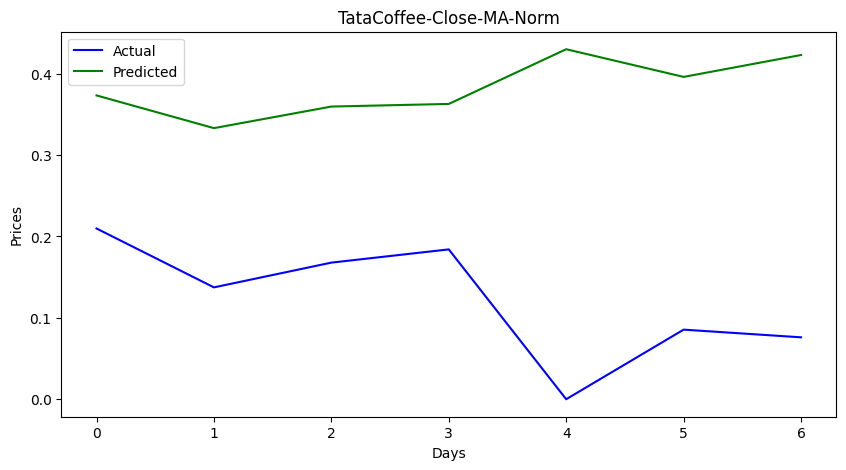

In [22]:
from stockFunctions import graph
graph(y_test,y_pred,"Actual","Predicted","TataCoffee-Close-MA-Norm","Days","Prices")

In [23]:
len(data1)

144

In [24]:
from stockFunctions import conversionSingle
aTestNormTable=conversionSingle(y_test,[column])
actual_stock_price_test_ori=Ms.inverse_transform(aTestNormTable)
actual_stock_price_test_oriA=conversionSingle(actual_stock_price_test_ori,[column])

In [25]:
from stockFunctions import conversionSingle
pTestNormTable=conversionSingle(y_pred,[column])
predicted_stock_price_test_ori=Ms.inverse_transform(pTestNormTable)
predicted_stock_price_test_oriP=conversionSingle(predicted_stock_price_test_ori,[column])

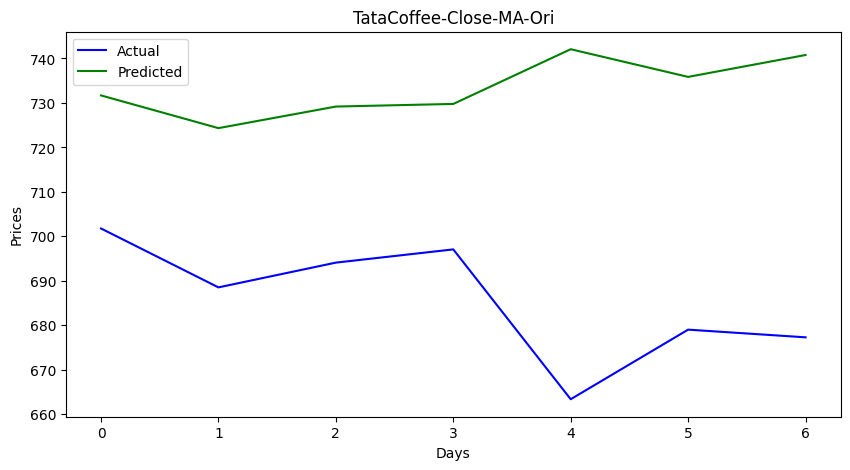

In [26]:
from stockFunctions import graph
graph(actual_stock_price_test_oriA,predicted_stock_price_test_oriP,"Actual","Predicted","TataCoffee-Close-MA-Ori","Days","Prices")

In [27]:
from stockFunctions import rmsemape
rmsemape(actual_stock_price_test_oriA,predicted_stock_price_test_oriP)

RMSE-Test: 50.591917174854224
maPe-Testset: 0.06970891423314149


In [28]:
forecast=model_fit.predict(len(data1), len(data1))

In [29]:
forecast

array([0.3867666])

In [30]:
from stockFunctions import conversionSingle
fTestNormTable=conversionSingle(forecast,["Closefore"])
forecast_stock_price_test_ori=Ms.inverse_transform(fTestNormTable)
forecast_stock_price_test_oriF=conversionSingle(forecast_stock_price_test_ori,["Closefore"])

In [31]:
forecast_stock_price_test_oriF

,Closefore
0,734.14475


In [32]:
forecast_stock_price_test_oriF.to_csv("CloseMA.csv",index=False)